In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/raw/Student_Feedback.csv",
    encoding="latin-1"
)

print("Original shape:", df.shape)

# Remove exact duplicate raw comments
df_model = (
    df.drop_duplicates(subset=["comments"])
      .reset_index(drop=True)
)

print("Final comparison dataset:", df_model.shape)

Original shape: (1086, 2)
Final comparison dataset: (1063, 2)


In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df_model["cleaned_text"] = df_model["comments"].apply(clean_text)

print(df_model.columns.tolist())
print(df_model[["comments", "cleaned_text"]].head())

['comments', 'sentiments', 'cleaned_text']
                                            comments  \
0                TEACHERS HELP US IN CAREER BUILDING   
1  Having no technical knowledge about their taug...   
2  teacher should give us the practical knowledge...   
3                        better teaching methodology   
4                               best teaching method   

                                        cleaned_text  
0                teachers help us in career building  
1  having no technical knowledge about their taug...  
2  teacher should give us the practical knowledge...  
3                        better teaching methodology  
4                               best teaching method  


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2)
)

X_tfidf = tfidf.fit_transform(
    df_model["cleaned_text"]
)

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (1063, 3000)


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

tfidf_results = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_tfidf)

    score = silhouette_score(
        X_tfidf,
        labels
    )

    tfidf_results.append({
        "K": k,
        "Silhouette Score": score
    })

    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.0059
K = 3, Silhouette Score = 0.0089
K = 4, Silhouette Score = 0.0099
K = 5, Silhouette Score = 0.0090
K = 6, Silhouette Score = 0.0123
K = 7, Silhouette Score = 0.0129
K = 8, Silhouette Score = 0.0113


In [14]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

embeddings = model.encode(
    df_model["comments"].tolist(),
    show_progress_bar=True
)

print("SBERT embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

SBERT embedding shape: (1063, 384)


In [15]:
sbert_results = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(embeddings)

    score = silhouette_score(
        embeddings,
        labels
    )

    sbert_results.append({
        "K": k,
        "Silhouette Score": score
    })

    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.0807
K = 3, Silhouette Score = 0.0348
K = 4, Silhouette Score = 0.0322
K = 5, Silhouette Score = 0.0289
K = 6, Silhouette Score = 0.0347
K = 7, Silhouette Score = 0.0393
K = 8, Silhouette Score = 0.0388


In [16]:
comparison_df = pd.DataFrame({
    "K": range(2, 9),
    "TF-IDF Silhouette": [
        result["Silhouette Score"]
        for result in tfidf_results
    ],
    "SBERT Silhouette": [
        result["Silhouette Score"]
        for result in sbert_results
    ]
})

comparison_df

,K,TF-IDF Silhouette,SBERT Silhouette
0,2,0.005871,0.080693
1,3,0.008914,0.034818
2,4,0.009922,0.032158
3,5,0.008964,0.028884
4,6,0.012251,0.034657
5,7,0.012882,0.039268
6,8,0.011343,0.038766


In [17]:
best_tfidf = comparison_df.loc[
    comparison_df["TF-IDF Silhouette"].idxmax()
]

best_sbert = comparison_df.loc[
    comparison_df["SBERT Silhouette"].idxmax()
]

print(
    f"Best TF-IDF: "
    f"K={int(best_tfidf['K'])}, "
    f"Silhouette={best_tfidf['TF-IDF Silhouette']:.4f}"
)

print(
    f"Best SBERT: "
    f"K={int(best_sbert['K'])}, "
    f"Silhouette={best_sbert['SBERT Silhouette']:.4f}"
)

Best TF-IDF: K=7, Silhouette=0.0129
Best SBERT: K=2, Silhouette=0.0807


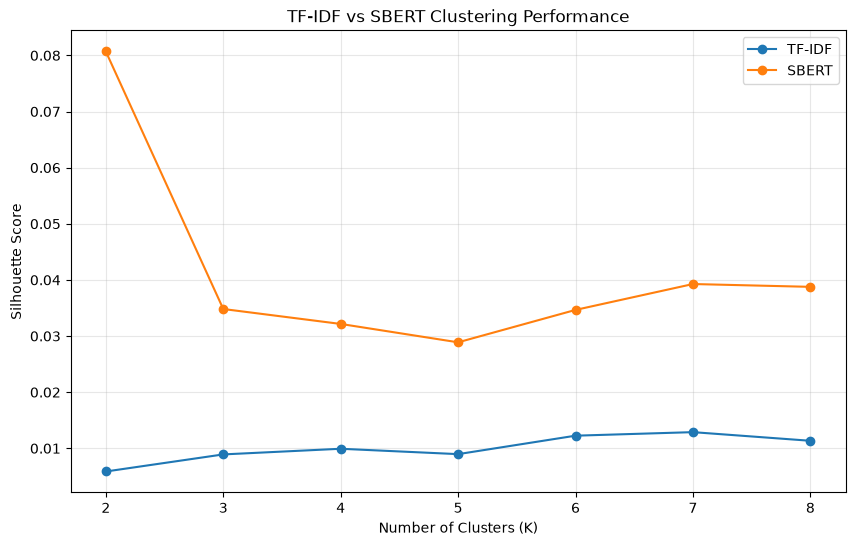

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    comparison_df["K"],
    comparison_df["TF-IDF Silhouette"],
    marker="o",
    label="TF-IDF"
)

plt.plot(
    comparison_df["K"],
    comparison_df["SBERT Silhouette"],
    marker="o",
    label="SBERT"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("TF-IDF vs SBERT Clustering Performance")

plt.xticks(range(2, 9))
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [19]:
# Final TF-IDF clustering with best K = 7

tfidf_kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

tfidf_final_labels = tfidf_kmeans.fit_predict(X_tfidf)

df_model["tfidf_final_cluster"] = tfidf_final_labels

print(
    df_model["tfidf_final_cluster"]
    .value_counts()
    .sort_index()
)

tfidf_final_cluster
0     69
1    449
2     62
3    121
4     73
5    177
6    112
Name: count, dtype: int64


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_centroids = tfidf_kmeans.cluster_centers_

for cluster in range(7):

    cluster_indices = np.where(
        tfidf_final_labels == cluster
    )[0]

    cluster_vectors = X_tfidf[cluster_indices]

    similarities = cosine_similarity(
        cluster_vectors,
        tfidf_centroids[cluster].reshape(1, -1)
    ).flatten()

    top_indices = similarities.argsort()[-10:][::-1]

    print("\n" + "=" * 70)
    print(f"CLUSTER {cluster} | SIZE: {len(cluster_indices)}")
    print("=" * 70)

    for rank, idx in enumerate(top_indices, 1):
        original_idx = cluster_indices[idx]

        print(
            f"{rank}. "
            f"{df_model.iloc[original_idx]['comments']}"
        )


CLUSTER 0 | SIZE: 69
1. teachers do not work hard
2. teachers do not prepare lectures
3. teachers do not satisfy to our queries
4. teachers do not make the subject interesting
5. teachers do not provide marked quizes 
6. teachers do not provided marked assignments in time
7. teachers do not follow time table strictly
8. teachers do not follow time table
9. teachers do not reply properly to our questions
10. do not complete work

CLUSTER 1 | SIZE: 449
1. First of all thank you sir. whatever you taught you taught well. you worked hard for us
2. Sir, you taught us very well
3. you taught us very well
4. You taught us very well
5. you taught us something that all in the world are talking about
6. you encourage us to learnt
7. sir thank you, you teach us in a very friendly environment
8. I rate you as good teacher
9. sir you taught we in an excellent manner but we were new entrants to this field of knowledge
10. lab work is not useful to us

CLUSTER 2 | SIZE: 62
1. he is very competitive t

In [22]:
tfidf_cluster_sizes = (
    df_model["tfidf_final_cluster"]
    .value_counts()
    .sort_index()
)

print("TF-IDF K=7 cluster sizes:")
print(tfidf_cluster_sizes)

print(df_model.columns.tolist())

print("SBERT K=7 cluster sizes:")
print(
    df_model["sbert_cluster_7"]
    .value_counts()
    .sort_index()
)

TF-IDF K=7 cluster sizes:
tfidf_final_cluster
0     69
1    449
2     62
3    121
4     73
5    177
6    112
Name: count, dtype: int64
['comments', 'sentiments', 'cleaned_text', 'tfidf_final_cluster']
SBERT K=7 cluster sizes:


KeyError: 'sbert_cluster_7'